In [26]:
#inisialisasi
import matplotlib.pyplot as plt
import numpy as np
import math

from qiskit import IBMQ, Aer, transpile, execute
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.providers.ibmq import least_busy

from qiskit.visualization import plot_histogram

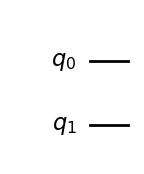

In [41]:
n = 2
gc = QuantumCircuit(n)
gc.draw('mpl')

In [42]:
def initialize_s(qc, qubits):
    #apply Hadamard ke dalam gc
    for q in qubits:
        qc.h(q)
    return qc

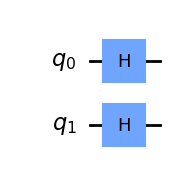

In [29]:
gc = initialize_s(gc, [0,1])
gc.draw('mpl')

mengaplikasikan oracle untuk $ |w> = |11> $ , oracle buat 2 qubit

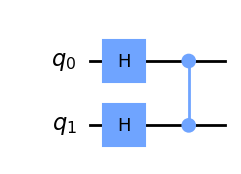

In [30]:
gc.cz(0,1)  #oracle
gc.draw('mpl')

mengaplikasikan diffuser $(Us)$ sebagai circuit inisialisasi $|s>$, membuat general diffuser (buat semua nomer qubit). jadi daoat dipakai dimasalah selanjutnya

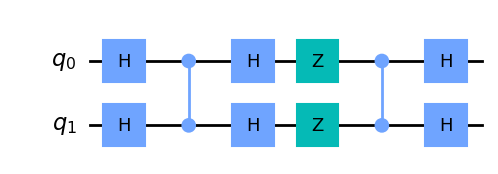

In [31]:
#operator diffusion
gc.h([0,1])
gc.z([0,1])
gc.cz(0,1)
gc.h([0,1])
#gc.barrier()
gc.draw('mpl')

In [32]:
#menjalankan simulasi
sv_sim = Aer.get_backend('statevector_simulator')
result = execute(gc, sv_sim).result()
statevec = result.get_statevector()

from qiskit.visualization import array_to_latex

array_to_latex(statevec, prefix="|\\psi\\rangle =")

<IPython.core.display.Latex object>

/mgpfs/home/nhandayani/.conda/envs/env-qo/lib/python3.9/site-packages/qiskit/visualization/counts_visualization.py:226: MatplotlibDeprecationWarning: The label function was deprecated in Matplotlib 3.1 and will be removed in 3.8. Use Tick.label1 instead.
  tick.label.set_fontsize(14)


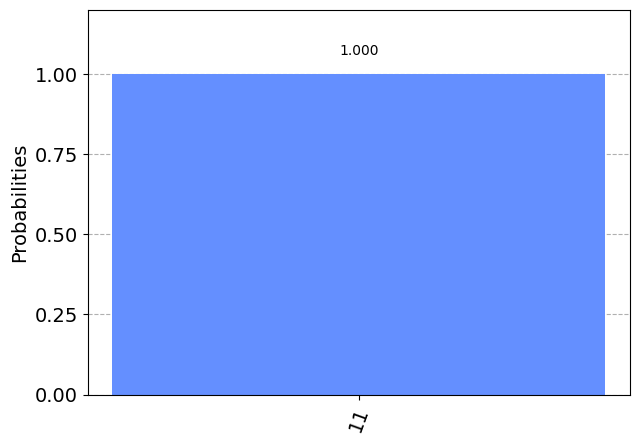

In [33]:
gc.measure_all()

qasm_sim = Aer.get_backend('qasm_simulator')
result = qasm_sim.run(gc).result()
counts = result.get_counts()
plot_histogram(counts)

Login ke akun IBM Quantum lalu memilih kompuuter kuantum IBM yang antreannya paling sedikit agar program berjalan cepat

In [34]:
'''
provider = IBMQ.load_account()
provider = IBMQ.get_provider("ibm-q")
device = least_busy(provider.backends(filters=lambda x: x.configuration().nqubits >= 3 and not x.configuration().simulator and x.status().operational==True))
print("Running on current least busy device: ", device)
'''

'\nprovider = IBMQ.load_account()\nprovider = IBMQ.get_provider("ibm-q")\ndevice = least_busy(provider.backends(filters=lambda x: x.configuration().nqubits >= 3 and not x.configuration().simulator and x.status().operational==True))\nprint("Running on current least busy device: ", device)\n'

In [36]:
'''
from qiskit.tools.monitor import job_monitor
transpiled_grover_circuit = transpile(gc, device, optimization_level=3)
job = device.run(transpiled_grover_circuit)
job_monitor = (job, interval=2)
'''

'\nfrom qiskit.tools.monitor import job_monitor\ntranspiled_grover_circuit = transpile(gc, device, optimization_level=3)\njob = device.run(transpiled_grover_circuit)\njob_monitor = (job, interval=2)\n'

In [37]:
'''
results = job.result()
answer = results.get_counts(gc)
plot_histogram(answer)
'''

'\nresults = job.result()\nanswer = results.get_counts(gc)\nplot_histogram(answer)\n'

mengimplementasikan grover diatas dengan contoh $$ n = 3 qubit $$ dan $$ target = |101> dan  |110> $$

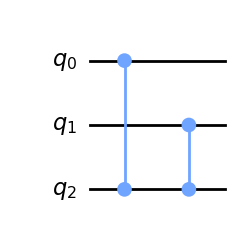

In [40]:
#buat oracle untuk keadaan |101> dan |110>
gc = QuantumCircuit(3)
gc.cz(0,2)
gc.cz(1,2)

gc.draw('mpl')
